In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("EV_vs_ICE_Vehicle_Specs_2015_2026.csv")

df.head()

,Make,Model,Year,Fuel_Type,Engine_Cylinders,Engine_Size_L,Drivetrain,Transmission,City_MPG,Highway_MPG,Combined_MPG,CO2_Emissions_g_per_mile,EV_Range_miles,Vehicle_Category
0,Nissan,GT-R,2015,Premium Gasoline,6.0,3.8,All-Wheel Drive,Automatic (AM6),16,23,19,472,0,ICE (Gas)
1,Volvo,S60 AWD,2015,Regular Gasoline,5.0,2.5,All-Wheel Drive,Automatic (S6),20,28,23,378,0,ICE (Gas)
2,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Automatic (S6),26,37,30,298,0,ICE (Gas)
3,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Automatic (S6),28,39,32,280,0,ICE (Gas)
4,Mazda,6,2015,Regular Gasoline,4.0,2.5,Front-Wheel Drive,Manual 6-spd,25,35,29,308,0,ICE (Gas)


In [5]:
df.shape

(15301, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15301 entries, 0 to 15300
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Make                      15301 non-null  object 
 1   Model                     15301 non-null  object 
 2   Year                      15301 non-null  int64  
 3   Fuel_Type                 15300 non-null  object 
 4   Engine_Cylinders          15301 non-null  float64
 5   Engine_Size_L             15301 non-null  float64
 6   Drivetrain                15301 non-null  object 
 7   Transmission              15301 non-null  object 
 8   City_MPG                  15301 non-null  int64  
 9   Highway_MPG               15301 non-null  int64  
 10  Combined_MPG              15301 non-null  int64  
 11  CO2_Emissions_g_per_mile  15301 non-null  int64  
 12  EV_Range_miles            15301 non-null  int64  
 13  Vehicle_Category          15301 non-null  object 
dtypes: flo

In [7]:
df.describe()

,Year,Engine_Cylinders,Engine_Size_L,City_MPG,Highway_MPG,Combined_MPG,CO2_Emissions_g_per_mile,EV_Range_miles
count,15301.000000,15301.000000,15301.000000,15301.000000,15301.000000,15301.000000,15301.000000,15301.000000
mean,2020.474348,5.041566,2.802464,28.005163,32.990850,29.748775,364.089929,37.779034
std,3.407711,2.378575,1.528925,23.870583,19.191434,21.699960,153.794166,108.485990
min,2015.000000,0.000000,0.000000,8.000000,11.000000,9.000000,0.000000,0.000000
25%,2018.000000,4.000000,2.000000,17.000000,23.000000,19.000000,310.000000,0.000000
50%,2020.000000,4.000000,2.500000,21.000000,28.000000,23.000000,385.000000,0.000000
75%,2023.000000,6.000000,3.600000,25.000000,33.000000,28.000000,459.000000,0.000000
max,2026.000000,16.000000,8.400000,153.000000,142.000000,146.000000,979.000000,640.000000


In [8]:
df.columns

Index(['Make', 'Model', 'Year', 'Fuel_Type', 'Engine_Cylinders',
       'Engine_Size_L', 'Drivetrain', 'Transmission', 'City_MPG',
       'Highway_MPG', 'Combined_MPG', 'CO2_Emissions_g_per_mile',
       'EV_Range_miles', 'Vehicle_Category'],
      dtype='object')

In [11]:
df.isnull().sum()

Make                        0
Model                       0
Year                        0
Fuel_Type                   1
Engine_Cylinders            0
Engine_Size_L               0
Drivetrain                  0
Transmission                0
City_MPG                    0
Highway_MPG                 0
Combined_MPG                0
CO2_Emissions_g_per_mile    0
EV_Range_miles              0
Vehicle_Category            0
dtype: int64

In [12]:
df[df["Fuel_Type"].isnull()]

,Make,Model,Year,Fuel_Type,Engine_Cylinders,Engine_Size_L,Drivetrain,Transmission,City_MPG,Highway_MPG,Combined_MPG,CO2_Emissions_g_per_mile,EV_Range_miles,Vehicle_Category
15259,Honda,CR-V e-FCEV,2025,NaN,0.0,0.0,Front-Wheel Drive,Automatic (A1),36,43,39,0,245,Hybrid/Other


In [13]:
df["Fuel_Type"] = df["Fuel_Type"].fillna("Unknown")

In [15]:
df.isnull().sum()

Make                        0
Model                       0
Year                        0
Fuel_Type                   0
Engine_Cylinders            0
Engine_Size_L               0
Drivetrain                  0
Transmission                0
City_MPG                    0
Highway_MPG                 0
Combined_MPG                0
CO2_Emissions_g_per_mile    0
EV_Range_miles              0
Vehicle_Category            0
dtype: int64

In [16]:
df.duplicated().sum()

0

In [18]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(col)
    print(df[col].value_counts())
    print("-" * 50)

Make
Make
BMW                      1275
Ford                     1055
Chevrolet                 988
Mercedes-Benz             971
Porsche                   891
                         ... 
Mobility Ventures LLC       2
STI                         1
Kandi                       1
Lordstown                   1
Mini                        1
Name: count, Length: 63, dtype: int64
--------------------------------------------------
Model
Model
Camaro                         76
Silverado 4WD                  66
Sierra 4WD                     61
Mustang                        58
Civic 4Dr                      50
                               ..
F150 5.0L 2WD GVWR>7599 LBS     1
F150 5.0L 4WD GVWR>7599 LBS     1
Spectre (23 inch wheels)        1
VF 9 Eco                        1
Valhalla                        1
Name: count, Length: 3079, dtype: int64
--------------------------------------------------
Fuel_Type
Fuel_Type
Premium Gasoline     7020
Regular Gasoline     6443
Electricity          1

In [19]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
numeric_cols

Index(['Year', 'Engine_Cylinders', 'Engine_Size_L', 'City_MPG', 'Highway_MPG',
       'Combined_MPG', 'CO2_Emissions_g_per_mile', 'EV_Range_miles'],
      dtype='object')

In [20]:
df[numeric_cols].describe()

,Year,Engine_Cylinders,Engine_Size_L,City_MPG,Highway_MPG,Combined_MPG,CO2_Emissions_g_per_mile,EV_Range_miles
count,15301.000000,15301.000000,15301.000000,15301.000000,15301.000000,15301.000000,15301.000000,15301.000000
mean,2020.474348,5.041566,2.802464,28.005163,32.990850,29.748775,364.089929,37.779034
std,3.407711,2.378575,1.528925,23.870583,19.191434,21.699960,153.794166,108.485990
min,2015.000000,0.000000,0.000000,8.000000,11.000000,9.000000,0.000000,0.000000
25%,2018.000000,4.000000,2.000000,17.000000,23.000000,19.000000,310.000000,0.000000
50%,2020.000000,4.000000,2.500000,21.000000,28.000000,23.000000,385.000000,0.000000
75%,2023.000000,6.000000,3.600000,25.000000,33.000000,28.000000,459.000000,0.000000
max,2026.000000,16.000000,8.400000,153.000000,142.000000,146.000000,979.000000,640.000000


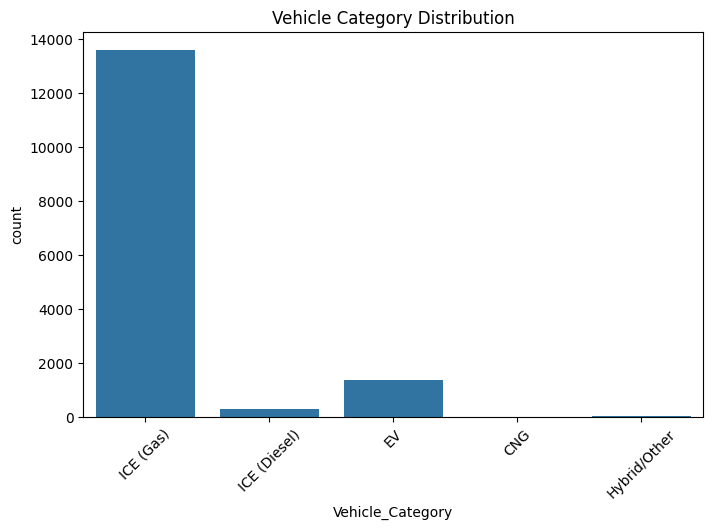

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Vehicle_Category")
plt.title("Vehicle Category Distribution")
plt.xticks(rotation=45)
plt.show()

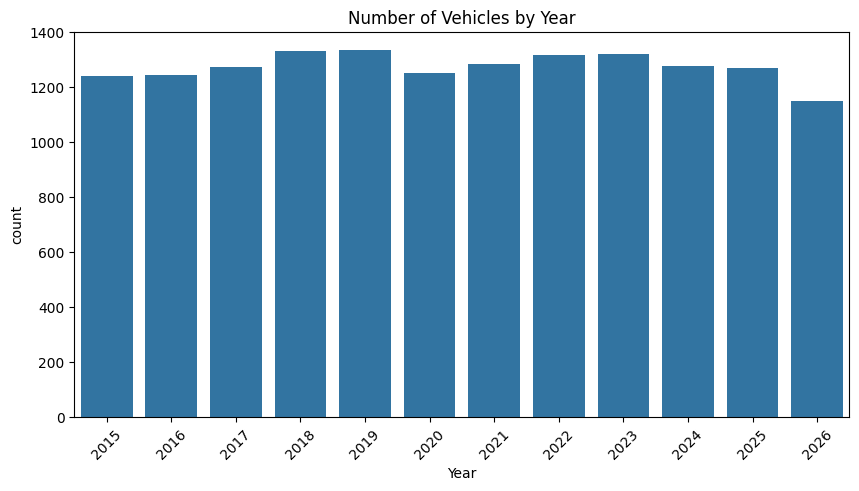

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Year")
plt.title("Number of Vehicles by Year")
plt.xticks(rotation=45)
plt.show()

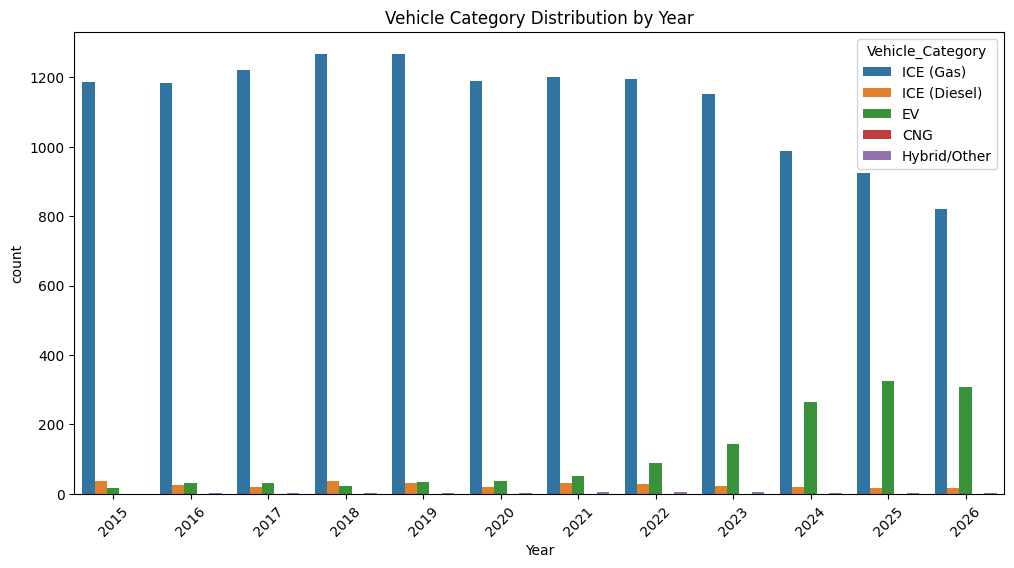

In [23]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Year", hue="Vehicle_Category")
plt.title("Vehicle Category Distribution by Year")
plt.xticks(rotation=45)
plt.show()

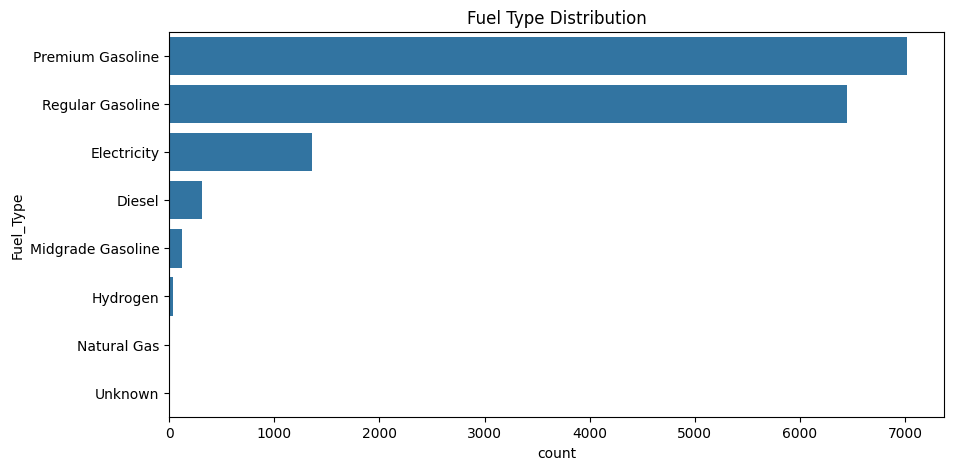

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="Fuel_Type", order=df["Fuel_Type"].value_counts().index)
plt.title("Fuel Type Distribution")
plt.show()

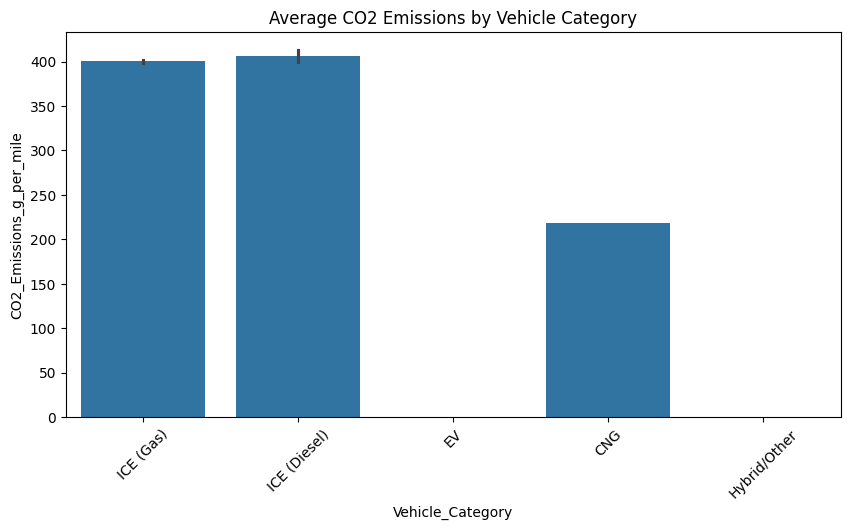

In [25]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Vehicle_Category", y="CO2_Emissions_g_per_mile")
plt.title("Average CO2 Emissions by Vehicle Category")
plt.xticks(rotation=45)
plt.show()

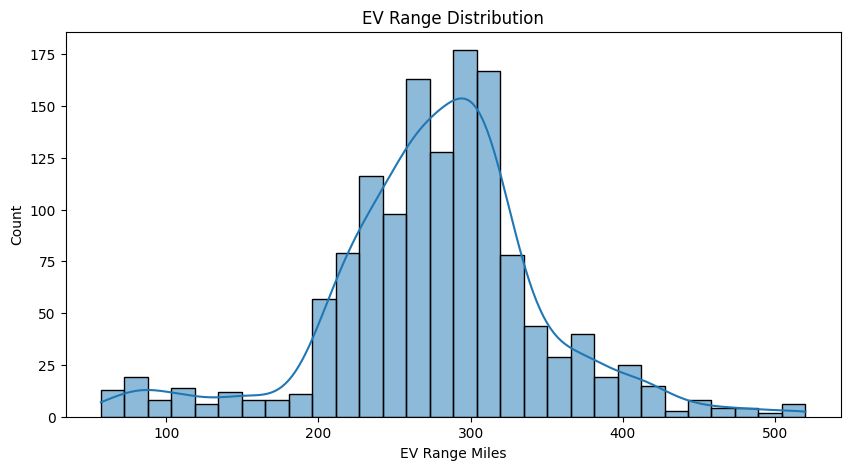

In [27]:
ev_df = df[df["Vehicle_Category"] == "EV"]

plt.figure(figsize=(10, 5))
sns.histplot(ev_df["EV_Range_miles"], bins=30, kde=True)
plt.title("EV Range Distribution")
plt.xlabel("EV Range Miles")
plt.show()

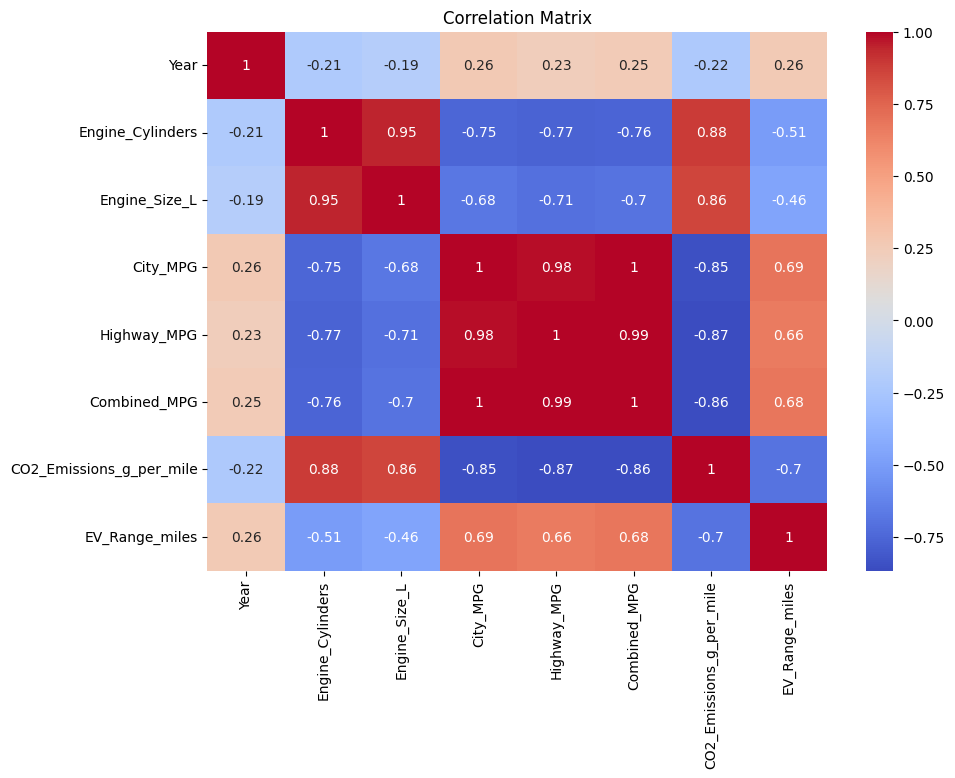

In [28]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [29]:
df_clean = df.copy()

df_clean = df_clean.drop(columns=["Model"])

In [30]:
def simplify_transmission(value):
    value = str(value).lower()
    
    if "manual" in value:
        return "Manual"
    elif "automatic" in value:
        return "Automatic"
    else:
        return "Other"

df_clean["Transmission_Type"] = df_clean["Transmission"].apply(simplify_transmission)
df_clean = df_clean.drop(columns=["Transmission"])

In [31]:
df_clean["Transmission_Type"].value_counts()

Transmission_Type
Automatic    13866
Manual        1435
Name: count, dtype: int64

In [32]:
df_clean[df_clean["Vehicle_Category"] == "EV"][["Engine_Cylinders", "Engine_Size_L"]].describe()

,Engine_Cylinders,Engine_Size_L
count,1361.0,1361.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


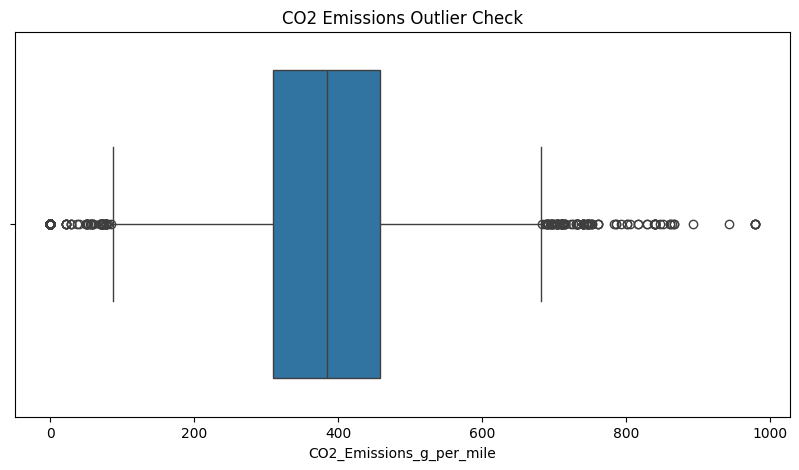

In [33]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="CO2_Emissions_g_per_mile")
plt.title("CO2 Emissions Outlier Check")
plt.show()

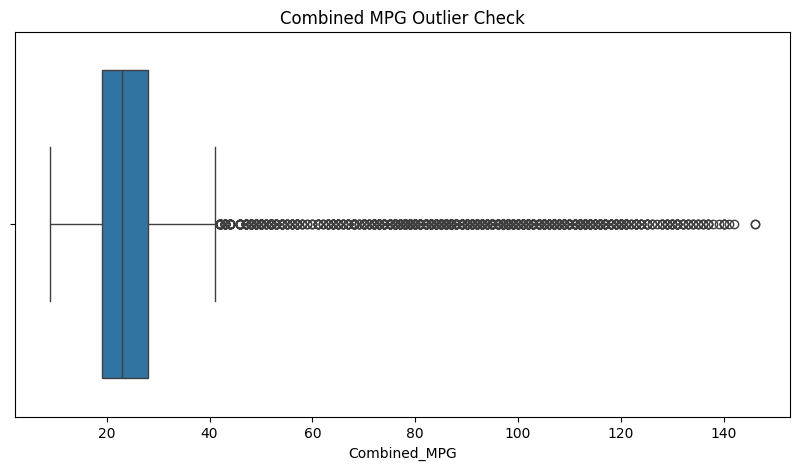

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="Combined_MPG")
plt.title("Combined MPG Outlier Check")
plt.show()

In [35]:
df_clean.sort_values("CO2_Emissions_g_per_mile", ascending=False).head(10)

,Make,Year,Fuel_Type,Engine_Cylinders,Engine_Size_L,Drivetrain,City_MPG,Highway_MPG,Combined_MPG,CO2_Emissions_g_per_mile,EV_Range_miles,Vehicle_Category,Transmission_Type
10918,Bugatti,2023,Premium Gasoline,16.0,8.0,All-Wheel Drive,8,11,9,979,0,ICE (Gas),Automatic
9538,Bugatti,2022,Premium Gasoline,16.0,8.0,All-Wheel Drive,8,11,9,979,0,ICE (Gas),Automatic
12022,Bugatti,2024,Premium Gasoline,16.0,8.0,All-Wheel Drive,8,11,9,979,0,ICE (Gas),Automatic
9537,Bugatti,2022,Premium Gasoline,16.0,8.0,All-Wheel Drive,8,11,9,979,0,ICE (Gas),Automatic
10919,Bugatti,2023,Premium Gasoline,16.0,8.0,All-Wheel Drive,8,11,9,979,0,ICE (Gas),Automatic
13583,Bugatti,2025,Premium Gasoline,16.0,8.0,All-Wheel Drive,8,12,9,943,0,ICE (Gas),Automatic
8545,Bugatti,2021,Premium Gasoline,16.0,8.0,All-Wheel Drive,8,13,10,893,0,ICE (Gas),Automatic
8817,Lamborghini,2021,Premium Gasoline,12.0,6.5,All-Wheel Drive,8,14,10,867,0,ICE (Gas),Automatic
8816,Lamborghini,2021,Premium Gasoline,12.0,6.5,All-Wheel Drive,8,14,10,867,0,ICE (Gas),Automatic
7684,Bugatti,2020,Premium Gasoline,16.0,8.0,All-Wheel Drive,9,13,10,864,0,ICE (Gas),Automatic


In [36]:
df_clean.sort_values("Combined_MPG", ascending=False).head(10)

,Make,Year,Fuel_Type,Engine_Cylinders,Engine_Size_L,Drivetrain,City_MPG,Highway_MPG,Combined_MPG,CO2_Emissions_g_per_mile,EV_Range_miles,Vehicle_Category,Transmission_Type
14960,Lucid,2026,Electricity,0.0,0.0,Rear-Wheel Drive,149,142,146,0,420,EV,Automatic
13381,Lucid,2025,Electricity,0.0,0.0,Rear-Wheel Drive,149,142,146,0,420,EV,Automatic
8880,Tesla,2021,Electricity,0.0,0.0,Rear-Wheel Drive,150,133,142,0,263,EV,Automatic
7356,Tesla,2020,Electricity,0.0,0.0,Rear-Wheel Drive,148,132,141,0,250,EV,Automatic
11330,Lucid,2023,Electricity,0.0,0.0,All-Wheel Drive,141,140,140,0,410,EV,Automatic
11973,Hyundai,2024,Electricity,0.0,0.0,Rear-Wheel Drive,153,127,140,0,361,EV,Automatic
11332,Lucid,2023,Electricity,0.0,0.0,All-Wheel Drive,141,140,140,0,425,EV,Automatic
11640,Hyundai,2023,Electricity,0.0,0.0,Rear-Wheel Drive,153,127,140,0,361,EV,Automatic
15240,Tesla,2026,Electricity,0.0,0.0,Rear-Wheel Drive,147,130,139,0,321,EV,Automatic
15029,Tesla,2026,Electricity,0.0,0.0,Rear-Wheel Drive,148,129,138,0,321,EV,Automatic


In [37]:
target = "Vehicle_Category"

X = df_clean.drop(columns=[target])
y = df_clean[target]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [40]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include="object").columns

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)

Numeric columns: Index(['Year', 'Engine_Cylinders', 'Engine_Size_L', 'City_MPG', 'Highway_MPG',
       'Combined_MPG', 'CO2_Emissions_g_per_mile', 'EV_Range_miles'],
      dtype='object')
Categorical columns: Index(['Make', 'Fuel_Type', 'Drivetrain', 'Transmission_Type'], dtype='object')


In [41]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [42]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape

(12240, 84)

In [43]:
df_clean.to_csv("cleaned_EV_vs_ICE_vehicle_specs.csv", index=False)